<a href="https://colab.research.google.com/github/Wosstarot/CSCI164/blob/main/Project_CSCI164_KevinTigson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [329]:
# Code by Kevin Tigson
# CSCI 164
# Project

In [330]:
#https://drive.google.com/file/d/1FG1B03bGaVVx2qWaz9J1dKgdb9bvYHm7/view?usp=sharing

!gdown 1FG1B03bGaVVx2qWaz9J1dKgdb9bvYHm7    #Download Wine Efficiency Dataset

#https://drive.google.com/file/d/1XpYFnACqSKzqvdIsUyf80Ddj-8wqMEnG/view?usp=sharing

!gdown 1XpYFnACqSKzqvdIsUyf80Ddj-8wqMEnG    #Download (Red) Wine Quality Dataset

Downloading...
From: https://drive.google.com/uc?id=1FG1B03bGaVVx2qWaz9J1dKgdb9bvYHm7
To: /content/ENB2012_data.csv
100% 40.7k/40.7k [00:00<00:00, 77.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XpYFnACqSKzqvdIsUyf80Ddj-8wqMEnG
To: /content/winequality-red.csv
100% 84.2k/84.2k [00:00<00:00, 94.7MB/s]


In [331]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Standardize
from sklearn.preprocessing import StandardScaler

#Encoders
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

#Split
#Cross-Validation
from sklearn.model_selection import train_test_split, cross_validate, KFold

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge

#Pipeline
##from sklearn.pipeline import Pipeline

# Model Tuning (Hyperparameter)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import validation_curve

#Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import metrics


In [332]:
"""
This first section is the code for the Energy Efficiency Dataset. The Wine Quality dataset is in a separate section after running the Energy Efficiency dataset through the machine learning process.
"""

'\nThis first section is the code for the Energy Efficiency Dataset. The Wine Quality dataset is in a separate section after running the Energy Efficiency dataset through the machine learning process.\n'

# Energy Efficiency Dataset

In [333]:
#Loading the dataset
energy = pd.read_csv('ENB2012_data.csv')
energy.head(10)

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46,25.38
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71,25.16
7,0.90,563.5,318.5,122.50,7.0,5,0.0,0,19.68,29.60
8,0.86,588.0,294.0,147.00,7.0,2,0.0,0,19.50,27.30
9,0.86,588.0,294.0,147.00,7.0,3,0.0,0,19.95,21.97


In [334]:
#X contains the input features of the dataset:
X= energy.iloc[:, 0:8]
#y contains the output features of the dataset:
y= energy.iloc[:, 8:10]
print(X.head())
print(y.head())

     X1     X2     X3      X4   X5  X6   X7  X8
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0
      Y1     Y2
0  15.55  21.33
1  15.55  21.33
2  15.55  21.33
3  15.55  21.33
4  20.84  28.28


Preprocessing:

In [335]:
#Prevent loss of original data by duplicating it before modification.
energy_encoded = energy.copy()

#One-Hot Encoding for X6 and X8 necessary to convert integers
labelsOrientation = OneHotEncoder(sparse_output=False).set_output(transform='pandas')

Orientation_df = labelsOrientation.fit_transform(energy_encoded[['X6', 'X8']])
Orientation_df

,X6_2,X6_3,X6_4,X6_5,X8_0,X8_1,X8_2,X8_3,X8_4,X8_5
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
763,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
764,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
765,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
766,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [336]:
# Standardize 'energy_continuous' features
#Select the numerical features to standardize
numerical_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
scaler = StandardScaler()
energy_encoded[numerical_cols] = scaler.fit_transform(energy_encoded[numerical_cols])

# ... (Rest of your code)


In [337]:
#Dataset of all integer features
energy_integer = energy[['X6', 'X8']]
energy_integer.head()

#Dataset of all continuous features
energy_continuous = energy[['X1', 'X2', 'X3', 'X4', 'X5', 'X7']]
energy_continuous.head()

# Standardize continuous features
scaler = StandardScaler()
energy_continuous_scaled = pd.DataFrame(
    scaler.fit_transform(energy_continuous),
    columns=energy_continuous.columns,
    index=energy_continuous.index
)

# Concatenate standardized continuous features with one-hot encoded Orientation
X_processed = pd.concat([energy_continuous_scaled, Orientation_df], axis=1)       # Variable containing the preprocessed data to model

print(X_processed)

           X1        X2        X3        X4   X5        X7  X6_2  X6_3  X6_4  \
0    2.041777 -1.785875 -0.561951 -1.470077  1.0 -1.760447   1.0   0.0   0.0   
1    2.041777 -1.785875 -0.561951 -1.470077  1.0 -1.760447   0.0   1.0   0.0   
2    2.041777 -1.785875 -0.561951 -1.470077  1.0 -1.760447   0.0   0.0   1.0   
3    2.041777 -1.785875 -0.561951 -1.470077  1.0 -1.760447   0.0   0.0   0.0   
4    1.284979 -1.229239  0.000000 -1.198678  1.0 -1.760447   1.0   0.0   0.0   
..        ...       ...       ...       ...  ...       ...   ...   ...   ...   
763 -1.174613  1.275625  0.561951  0.972512 -1.0  1.244049   0.0   0.0   0.0   
764 -1.363812  1.553943  1.123903  0.972512 -1.0  1.244049   1.0   0.0   0.0   
765 -1.363812  1.553943  1.123903  0.972512 -1.0  1.244049   0.0   1.0   0.0   
766 -1.363812  1.553943  1.123903  0.972512 -1.0  1.244049   0.0   0.0   1.0   
767 -1.363812  1.553943  1.123903  0.972512 -1.0  1.244049   0.0   0.0   0.0   

     X6_5  X8_0  X8_1  X8_2  X8_3  X8_4

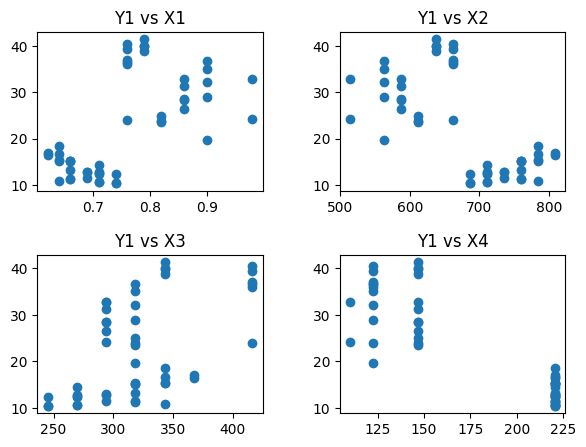

In [338]:
#5.4
#Scatter plots

# take a random sample of 50 instances
df = energy.sample(n=50, random_state=1234)
df.head()

# Plot y1,y2 vs X1-X-8
fig, axis = plt.subplots(2, 2)
fig.tight_layout(pad=2.5)
axis[0, 0].scatter(df[['X1']], df[['Y1']])
axis[0, 0].set_title("Y1 vs X1")
axis[0, 1].scatter(df[['X2']], df[['Y1']])
axis[0, 1].set_title("Y1 vs X2")
axis[1, 0].scatter(df[['X3']], df[['Y1']])
axis[1, 0].set_title("Y1 vs X3")
axis[1, 1].scatter(df[['X4']], df[['Y1']])
axis[1, 1].set_title("Y1 vs X4")
plt.show()


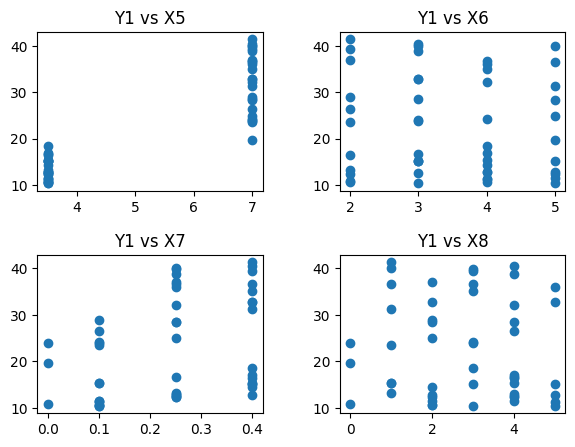

In [339]:
#5.4
#Scatter plots

# take a random sample of 50 instances
df = energy.sample(n=50, random_state=1234)
df.head()

# Plot y1,y2 vs X1-X-8
fig, axis = plt.subplots(2, 2)
fig.tight_layout(pad=2.5)
axis[0, 0].scatter(df[['X5']], df[['Y1']])
axis[0, 0].set_title("Y1 vs X5")
axis[0, 1].scatter(df[['X6']], df[['Y1']])
axis[0, 1].set_title("Y1 vs X6")
axis[1, 0].scatter(df[['X7']], df[['Y1']])
axis[1, 0].set_title("Y1 vs X7")
axis[1, 1].scatter(df[['X8']], df[['Y1']])
axis[1, 1].set_title("Y1 vs X8")
plt.show()


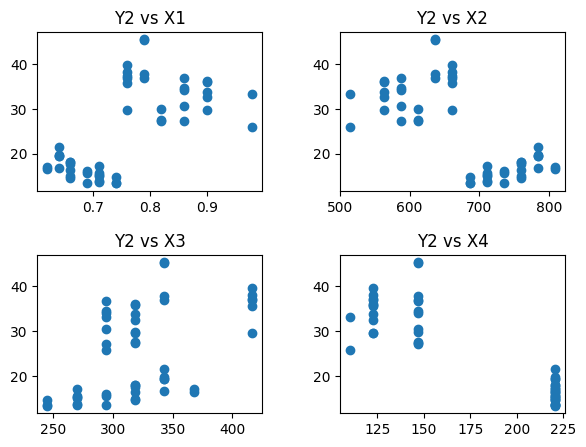

In [340]:
#5.4
#Scatter plots

# take a random sample of 50 instances
df = energy.sample(n=50, random_state=1234)
df.head()

# Plot y1,y2 vs X1-X-8
fig, axis = plt.subplots(2, 2)
fig.tight_layout(pad=2.5)
axis[0, 0].scatter(df[['X1']], df[['Y2']])
axis[0, 0].set_title("Y2 vs X1")
axis[0, 1].scatter(df[['X2']], df[['Y2']])
axis[0, 1].set_title("Y2 vs X2")
axis[1, 0].scatter(df[['X3']], df[['Y2']])
axis[1, 0].set_title("Y2 vs X3")
axis[1, 1].scatter(df[['X4']], df[['Y2']])
axis[1, 1].set_title("Y2 vs X4")
plt.show()


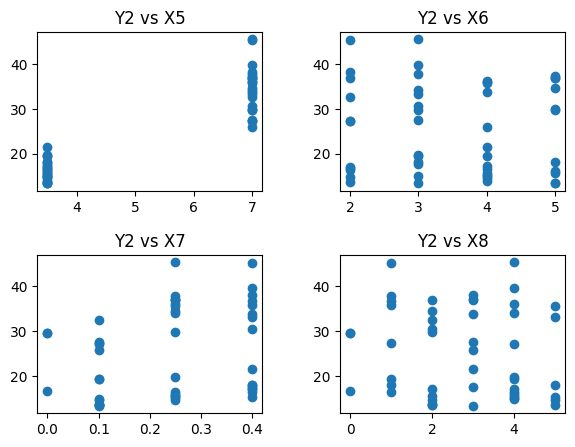

In [341]:
#5.4
#Scatter plots

# take a random sample of 50 instances
df = energy.sample(n=50, random_state=1234)
df.head()

# Plot y1,y2 vs X1-X-8
fig, axis = plt.subplots(2, 2)
fig.tight_layout(pad=2.5)
axis[0, 0].scatter(df[['X5']], df[['Y2']])
axis[0, 0].set_title("Y2 vs X5")
axis[0, 1].scatter(df[['X6']], df[['Y2']])
axis[0, 1].set_title("Y2 vs X6")
axis[1, 0].scatter(df[['X7']], df[['Y2']])
axis[1, 0].set_title("Y2 vs X7")
axis[1, 1].scatter(df[['X8']], df[['Y2']])
axis[1, 1].set_title("Y2 vs X8")
plt.show()


Cross-Validation/Split Data:

In [342]:
#Split training and testing (10%) data:
X_train_val, X_test, y_train_val, y_test = train_test_split(X_processed, y, test_size=0.1, random_state=11)
# Split again for validation (10%) and training data (80%)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1111, random_state=11)

#Cross-Validation
# Define a set of 10 cross-validation folds with random_state(For reproducibility)
kf = KFold(n_splits=5, random_state=42, shuffle=True)

Initialize and test baseline

In [343]:
# Initialize a (Least Squares) linear regression model
SLRModelEnergy_base = LinearRegression()

# Initialize a Knnr regressor model
KNRegressorModelEnergy_base = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)          #Default hyperparameters

# Initialize a third model
elasticNetModelEnergy_base = ElasticNet(alpha=1, l1_ratio=0.5, max_iter=1000)


In [344]:
# Linear model performance on testing
#SLRModel.fit(X_train, np.ravel(y_train))
#SLRModel.score(X_test, np.ravel(y_test))
# Training:
SLRModelEnergy_base.fit(X_train, y_train) # Remove np.ravel and use the original y_train DataFrame

print(X_train.columns)
print(SLRModelEnergy_base.coef_)
print(SLRModelEnergy_base.intercept_)



# Training:
KNRegressorModelEnergy_base.fit(X_train, y_train)

#print(KNRegressorModel.coef_)
#print(KNRegressorModel.intercept_)

# Training:
elasticNetModelEnergy_base.fit(X_train, y_train)

print(elasticNetModelEnergy_base.coef_)
print(elasticNetModelEnergy_base.intercept_)





Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X7', 'X6_2', 'X6_3', 'X6_4', 'X6_5',
       'X8_0', 'X8_1', 'X8_2', 'X8_3', 'X8_4', 'X8_5'],
      dtype='object')
[[-6.50227419 -3.55706749  0.80205789 -3.85599353  7.30294796  2.17797523
   0.02170204  0.0809527  -0.14102083  0.03836609 -3.72313596  0.97500537
   0.73759398  0.65092639  0.77543748  0.58417274]
 [-6.87811579 -3.46213951  0.12733629 -3.43756364  7.86778999  1.76574984
   0.00838007 -0.14604442 -0.1419746   0.27963894 -1.53156614  0.6359546
   0.33110977  0.09681835  0.42172781  0.04595561]]
[21.79606679 24.3959967 ]
[[ 0.51154594 -0.96403341  1.89230895 -2.31162272  2.93434383  1.40045184
  -0.          0.         -0.         -0.         -0.          0.
   0.          0.          0.          0.        ]
 [ 0.47130363 -0.95209392  1.57335384 -2.14595624  2.85150909  0.92739905
   0.         -0.         -0.          0.         -0.          0.
   0.          0.          0.          0.        ]]
[22.29176577 24.62061967]


In [345]:
print("THIS Prints out the BASELINE metrics without hyperparameter tuning")
# Metrics
SLRPredict = SLRModelEnergy_base.predict(X_test)
KNRegressorPredict = KNRegressorModelEnergy_base.predict(X_test)
elasticNetPredict = elasticNetModelEnergy_base.predict(X_test)

#Metrics Testing
SLRModelEnergy_base.score(X_test, y_test)  # Remove np.ravel and use the original y_test DataFrame
print()
print("Least Squared Linear Regression metrics:")
print('R^2:', r2_score(y_test, SLRPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, SLRPredict)))
print('MAE:', mean_absolute_error(y_test, SLRPredict))
print('MSE:', mean_squared_error(y_test, SLRPredict))



#Metrics Testing
KNRegressorModelEnergy_base.score(X_test, y_test)
print()
print("KNN Regression metrics:")
print('R^2:', r2_score(y_test, KNRegressorPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, KNRegressorPredict)))
print('MAE:', mean_absolute_error(y_test, KNRegressorPredict))
print('MSE:', mean_squared_error(y_test, KNRegressorPredict))



#Metrics Testing
elasticNetModelEnergy_base.score(X_test, y_test)
print()
print("Elastic Net metrics:")
print('R^2:', r2_score(y_test, elasticNetPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, elasticNetPredict)))
print('MAE:', mean_absolute_error(y_test, elasticNetPredict))
print('MSE:', mean_squared_error(y_test, elasticNetPredict))








THIS Prints out the BASELINE metrics without hyperparameter tuning

Least Squared Linear Regression metrics:
R^2: 0.9177429554254065
RMSE: 2.7862549812251043
MAE: 1.9657228970507492
MSE: 7.763216820401707

KNN Regression metrics:
R^2: 0.9375437493739922
RMSE: 2.4232937068400084
MAE: 1.7670259740259748
MSE: 5.8723523896103895

Elastic Net metrics:
R^2: 0.8319873872107597
RMSE: 3.9961011805555415
MAE: 3.070589035827072
MSE: 15.968824645237394


BASELINE prediction error graphs

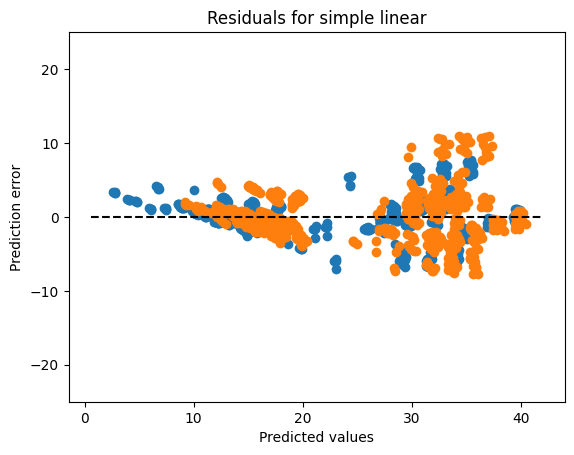

In [346]:
# Find predicted values
yPredicted_simpLin = SLRModelEnergy_base.predict(X_processed)

# Compute prediction errors
yError_simpLin = y - yPredicted_simpLin

# Plot prediction errors vs predicted values
fig = plt.figure()
plt.scatter(yPredicted_simpLin[:, 0], yError_simpLin['Y1'])  # Access the first column for x-axis
plt.scatter(yPredicted_simpLin[:, 1], yError_simpLin['Y2'])  # Access the second column for x-axis
plt.title('Residuals for simple linear')
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
plt.ylim(-25, 25)

# Add dashed line at y=0
# Get min/max from the first column of predictions (adjust column index if needed)
plt.plot([yPredicted_simpLin[:, 0].min() - 2, yPredicted_simpLin[:, 0].max() + 2], [0, 0], linestyle='dashed', color='black')

plt.show()

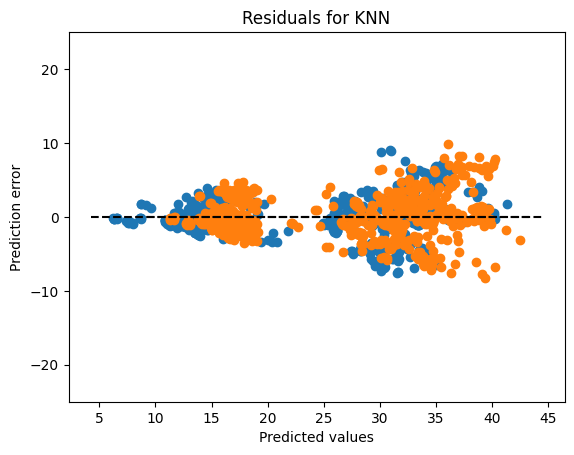

In [347]:
# Find predicted values
yPredicted_knnr = KNRegressorModelEnergy_base.predict(X_processed)

# Compute prediction errors
yError_knnr = y - yPredicted_knnr

# Plot prediction errors vs predicted values
fig = plt.figure()
plt.scatter(yPredicted_knnr[:, 0], yError_knnr['Y1'])  # Access the first column for x-axis
plt.scatter(yPredicted_knnr[:, 1], yError_knnr['Y2'])  # Access the second column for x-axis

plt.title('Residuals for KNN')
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
plt.ylim(-25, 25)

# Add dashed line at y=0
# Get min/max from the first column of predictions (adjust column index if needed)
plt.plot([yPredicted_knnr[:, 0].min() - 2, yPredicted_knnr[:, 0].max() + 2], [0, 0], linestyle='dashed', color='black')
plt.plot([yPredicted_knnr[:, 1].min() - 2, yPredicted_knnr[:, 1].max() + 2], [0, 0], linestyle='dashed', color='black')

plt.show()


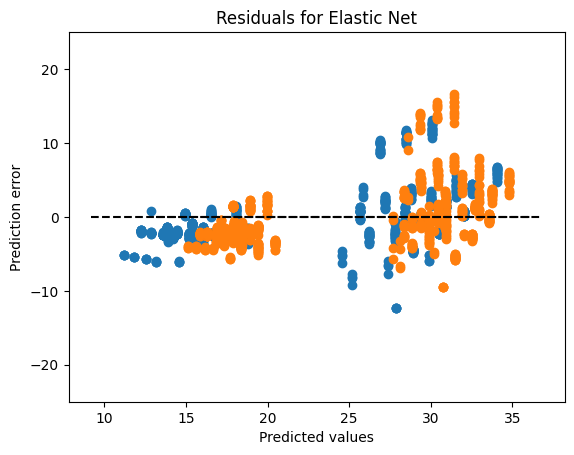

In [348]:
# Find predicted values
yPredicted_elasticNet = elasticNetModelEnergy_base.predict(X_processed)

# Compute prediction errors
yError_elasticNet = y - yPredicted_elasticNet

# Plot prediction errors vs predicted values
fig = plt.figure()
plt.scatter(yPredicted_elasticNet[:, 0], yError_elasticNet['Y1'])  # Access the first column for x-axis
plt.scatter(yPredicted_elasticNet[:, 1], yError_elasticNet['Y2'])  # Access the second column for x-axis

plt.title('Residuals for Elastic Net')
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
plt.ylim(-25, 25)

# Add dashed line at y=0
# Get min/max from the first column of predictions (adjust column index if needed)
plt.plot([yPredicted_elasticNet[:, 0].min() - 2, yPredicted_elasticNet[:, 0].max() + 2], [0, 0], linestyle='dashed', color='black')
plt.plot([yPredicted_elasticNet[:, 1].min() - 2, yPredicted_elasticNet[:, 1].max() + 2], [0, 0], linestyle='dashed', color='black')

plt.show()


Initialize Models with Tuning Grid:

In [349]:
# Initialize a (Least Squares) linear regression model
SLRModelEnergy = LinearRegression()

# Initialize a Knnr regressor model
KNRegressorModelEnergy = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)          #Default hyperparameters

# Create a tuning grid for GridSearchCV.
k = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]}
# Initialize the tuning grid
knnTuning = GridSearchCV(KNRegressorModelEnergy, k, cv=kf)
# Fit the grid to the training data
knnTuning.fit(X_train, y_train)#np.ravel(y_train))


# Initialize a third model
elasticNetModelEnergy = ElasticNet(alpha=1, l1_ratio=0.5, max_iter=1000)
elasticTuning = GridSearchCV(elasticNetModelEnergy, {'alpha': [0.1, 0.3, 0.5, 0.7, 0.9, 1, 2], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}, cv=kf)
elasticTuning.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=ElasticNet(alpha=1),
             param_grid={'alpha': [0.1, 0.3, 0.5, 0.7, 0.9, 1, 2],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]})

Validation Curves

Text(0, 0.5, 'Score')

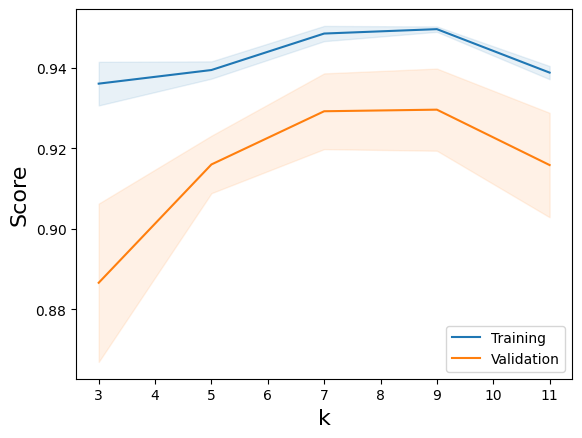

In [350]:
#KNN Validation Curve #1:
k = [3, 5, 7, 9, 11]
train_scores, test_scores = validation_curve(KNRegressorModelEnergy, X_train, y_train,
                                              param_range=k,
                                              param_name='n_neighbors',
                                              cv=5)
                                              #scoring='neg_mean_squared_error'n_jobs????


# Calculate mean and SD for training and testing
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot cross-validation results on training/validation for each parameter value
sns.lineplot(x=k, y=train_scores_mean, label='Training', color='#1f77b4')
sns.lineplot(x=k, y=test_scores_mean, label='Validation', color='#ff7f0e')
plt.fill_between(k, train_scores_mean-train_scores_std, train_scores_mean+train_scores_std,
                 alpha=0.1, color='#1f77b4')
plt.fill_between(k, test_scores_mean-test_scores_std, test_scores_mean+test_scores_std,
                 alpha=0.1, color='#ff7f0e')

plt.xlabel('k', fontsize=16)
plt.ylabel('Score', fontsize=16)

Text(0, 0.5, 'Score')

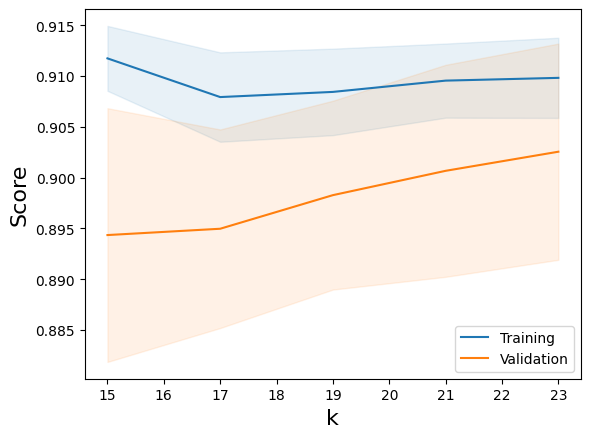

In [351]:
#KNN validation Curve #2
k = [15, 17, 19, 21, 23]
train_scores, test_scores = validation_curve(KNRegressorModelEnergy, X_train, y_train,
                                              param_range=k,
                                              param_name='n_neighbors',
                                              cv=5)
                                              #scoring='neg_mean_squared_error'n_jobs????


# Calculate mean and SD for training and testing
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot cross-validation results on training/validation for each parameter value
sns.lineplot(x=k, y=train_scores_mean, label='Training', color='#1f77b4')
sns.lineplot(x=k, y=test_scores_mean, label='Validation', color='#ff7f0e')
plt.fill_between(k, train_scores_mean-train_scores_std, train_scores_mean+train_scores_std,
                 alpha=0.1, color='#1f77b4')
plt.fill_between(k, test_scores_mean-test_scores_std, test_scores_mean+test_scores_std,
                 alpha=0.1, color='#ff7f0e')

plt.xlabel('k', fontsize=16)
plt.ylabel('Score', fontsize=16)

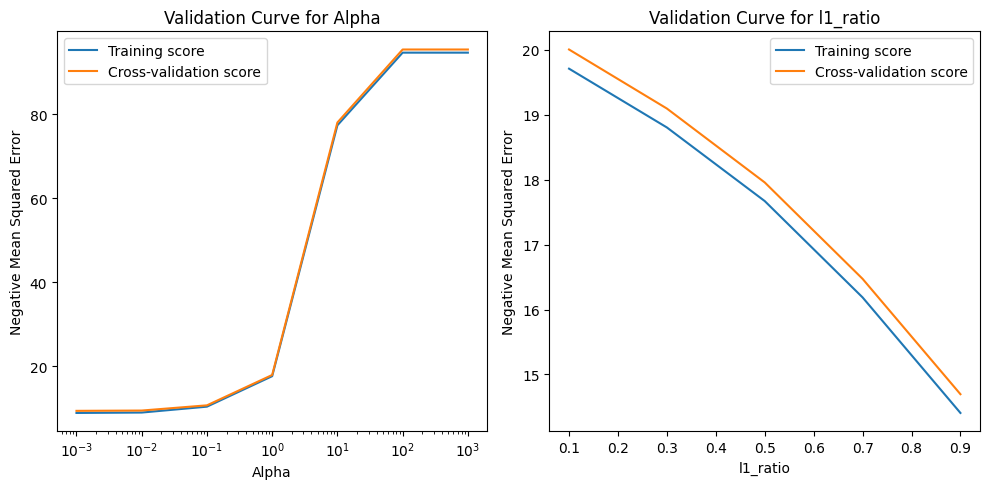

In [352]:
# prompt: Validation curve for Elastic Net:

# Elastic Net Validation Curve
alpha_range = np.logspace(-3, 3, 7)  # Example alpha range
l1_ratio_range = np.linspace(0.1, 0.9, 5) # Example l1_ratio range

# Validation curve for alpha
train_scores_alpha, test_scores_alpha = validation_curve(
    elasticNetModelEnergy, X_train, y_train, param_name="alpha", param_range=alpha_range, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1
)

# Validation curve for l1_ratio
train_scores_l1, test_scores_l1 = validation_curve(
    elasticNetModelEnergy, X_train, y_train, param_name="l1_ratio", param_range=l1_ratio_range, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1
)


# Plotting the validation curves
plt.figure(figsize=(10, 5))

# Plot for alpha
plt.subplot(1, 2, 1)
plt.plot(alpha_range, -np.mean(train_scores_alpha, axis=1), label="Training score")
plt.plot(alpha_range, -np.mean(test_scores_alpha, axis=1), label="Cross-validation score")
plt.title("Validation Curve for Alpha")
plt.xlabel("Alpha")
plt.ylabel("Negative Mean Squared Error")
plt.legend()
plt.xscale("log") # Use logarithmic scale for alpha

# Plot for l1_ratio
plt.subplot(1, 2, 2)
plt.plot(l1_ratio_range, -np.mean(train_scores_l1, axis=1), label="Training score")
plt.plot(l1_ratio_range, -np.mean(test_scores_l1, axis=1), label="Cross-validation score")
plt.title("Validation Curve for l1_ratio")
plt.xlabel("l1_ratio")
plt.ylabel("Negative Mean Squared Error")
plt.legend()

plt.tight_layout()
plt.show()


<Axes: >

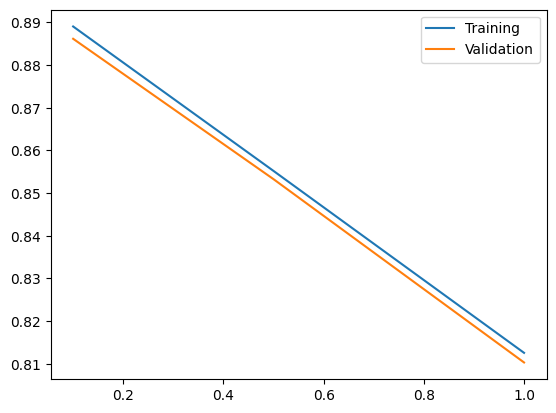

In [353]:
elastic = [0.1, 0.5, 1]
train_scores, test_scores = validation_curve(elasticNetModelEnergy, X_train, y_train,
                                              param_range=elastic,
                                              param_name='alpha',
                                              cv=5)

# Calculate mean and SD for training and testing for elastic net
train_scores_mean = np.mean(train_scores, axis=1) # Calculate mean for elastic net
train_scores_std = np.std(train_scores, axis=1)  # Calculate std for elastic net
test_scores_mean = np.mean(test_scores, axis=1)   # Calculate mean for elastic net
test_scores_std = np.std(test_scores, axis=1)    # Calculate std for elastic net


sns.lineplot(x=elastic, y=train_scores_mean, label='Training', color='#1f77b4')
sns.lineplot(x=elastic, y=test_scores_mean, label='Validation', color='#ff7f0e')

<Axes: >

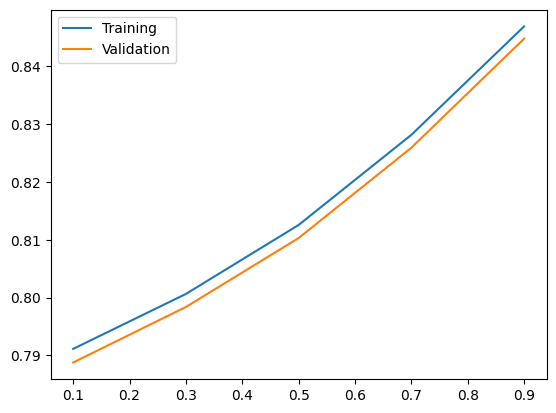

In [354]:
l1_ratio_range = np.linspace(0.1, 0.9, 5) # Example l1_ratio range

train_scores, test_scores = validation_curve(elasticNetModelEnergy, X_train, y_train,
                                              param_range=l1_ratio_range,
                                              param_name='l1_ratio',
                                              cv=5)

# Calculate mean and SD for training and testing for elastic net
train_scores_mean = np.mean(train_scores, axis=1) # Calculate mean for elastic net
train_scores_std = np.std(train_scores, axis=1)  # Calculate std for elastic net
test_scores_mean = np.mean(test_scores, axis=1)   # Calculate mean for elastic net
test_scores_std = np.std(test_scores, axis=1)    # Calculate std for elastic net


sns.lineplot(x=l1_ratio_range, y=train_scores_mean, label='Training', color='#1f77b4')
sns.lineplot(x=l1_ratio_range, y=test_scores_mean, label='Validation', color='#ff7f0e')

Model Tuning

In [355]:
knnTuning.cv_results_

{'mean_fit_time': array([0.00244994, 0.0021925 , 0.00240631, 0.00218334, 0.00240555,
        0.00218863, 0.0021606 , 0.00229568, 0.00218306, 0.00230865,
        0.00234985, 0.00221009]),
 'std_fit_time': array([5.41229676e-04, 2.24301077e-05, 2.93649331e-04, 4.35176544e-05,
        3.86260868e-04, 5.38816283e-05, 1.11343263e-05, 2.49300271e-04,
        5.92725275e-05, 2.66503234e-04, 1.77519372e-04, 4.21086360e-05]),
 'mean_score_time': array([0.00304365, 0.00297484, 0.00340004, 0.00319438, 0.00336361,
        0.00328717, 0.00332499, 0.00377469, 0.00343652, 0.00394306,
        0.00371513, 0.00382695]),
 'std_score_time': array([1.71217809e-04, 1.14613205e-04, 2.76677890e-04, 1.69106209e-04,
        2.48775638e-04, 1.45171630e-04, 4.69487289e-05, 8.12791287e-04,
        6.64419838e-05, 5.11246571e-04, 3.94118532e-05, 1.66873018e-04]),
 'param_n_neighbors': masked_array(data=[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25],
              mask=[False, False, False, False, False, False, False,

In [356]:
print(len([key for key in knnTuning.cv_results_.keys() if 'split' in key]))


5


In [357]:
# Mean testing score for each k and best hyperparameters
print('Mean testing scores:', knnTuning.cv_results_['mean_test_score'])
print("\nAccording to the GridSearchCV results, the best hyperparameter value is:", knnTuning.best_estimator_)


Mean testing scores: [0.88040433 0.9123814  0.9302708  0.93076564 0.9157268  0.90150735
 0.89688148 0.89627221 0.89824682 0.90010333 0.90131554 0.90307515]

According to the GridSearchCV results, the best hyperparameter value is: KNeighborsRegressor(n_neighbors=9)


In [358]:
elasticTuning.cv_results_

{'mean_fit_time': array([0.00353432, 0.00364242, 0.00395312, 0.00381179, 0.00400324,
        0.00340819, 0.00309134, 0.00471964, 0.00332704, 0.00339413,
        0.00295224, 0.00311966, 0.00302916, 0.00297503, 0.00340915,
        0.00332203, 0.00316825, 0.00279288, 0.00327411, 0.00309911,
        0.00279784, 0.00286417, 0.00289607, 0.00289769, 0.00287309,
        0.00332785, 0.00284286, 0.00272808, 0.00278168, 0.00289145,
        0.00273514, 0.0027184 , 0.00269933, 0.00299726, 0.00276518]),
 'std_fit_time': array([4.50688058e-05, 2.18855197e-04, 2.86005186e-04, 9.78280443e-05,
        4.96434714e-04, 4.99176131e-04, 1.77089900e-04, 7.17649295e-04,
        1.00399374e-04, 2.86032231e-04, 8.11369777e-05, 3.08896730e-04,
        8.84935000e-05, 3.16324585e-05, 5.99827542e-04, 7.18546412e-04,
        5.54384128e-04, 2.94395879e-05, 6.78866693e-04, 2.06374307e-04,
        6.44102695e-05, 7.37578461e-05, 1.31582866e-04, 1.71033718e-05,
        4.50661823e-05, 4.33348366e-04, 2.16639900e-04, 6

In [359]:
# Mean testing score
print('Mean testing scores:', elasticTuning.cv_results_['mean_test_score'])
print("\nAccording to the GridSearchCV results, the best hyperparameter value is:", elasticTuning.best_estimator_)


Mean testing scores: [0.87889966 0.88117317 0.88398658 0.88724988 0.8908804  0.85662841
 0.86164318 0.86688919 0.87266383 0.88056794 0.83690521 0.84344129
 0.85119575 0.86021142 0.87190889 0.81687484 0.82492526 0.83455229
 0.84693714 0.86151589 0.7966504  0.8058469  0.81718541 0.83194939
 0.84926814 0.78656344 0.79617253 0.80818191 0.8238225  0.84244722
 0.6915714  0.70078447 0.71256682 0.72817757 0.75134875]

According to the GridSearchCV results, the best hyperparameter value is: ElasticNet(alpha=0.1, l1_ratio=0.9)


In [360]:
knnTuning_best = knnTuning.best_estimator_

elasticTuning_best = elasticTuning.best_estimator_


In [361]:
# Post-Tuning Validation Scores

# Linear Regression:
# Fit simple linear regression with cross-validation to the training data (SLRModel stores results and both training and validation scores)
SLRModelResults = cross_validate(SLRModelEnergy, X_train, y_train, cv=kf, return_train_score=True)    #Cross validate trains model based on folds (train_test_score tests for overfitting)
# Find the test score for each fold
SLR_ValidationScores = SLRModelResults['test_score']
print('Simple linear regression scores:', SLR_ValidationScores.round(3))                        #Display test scores to the third decimal

# KNNModel:
KNNModelResults = cross_validate(knnTuning_best, X_train, y_train, cv=kf, return_train_score=True)
KNRegressor_ValidationScores = KNNModelResults['test_score']
print('KNN scores:', KNRegressor_ValidationScores.round(3))

# Elastic Net:
elasticNetModelResults = cross_validate(elasticTuning_best, X_train, y_train, cv=kf, return_train_score=True)
elasticNet_ValidationScores = elasticNetModelResults['test_score']
print('Elastic Net scores:', elasticNet_ValidationScores.round(3))

Simple linear regression scores: [0.894 0.906 0.9   0.915 0.871]
KNN scores: [0.925 0.946 0.93  0.936 0.916]
Elastic Net scores: [0.897 0.901 0.891 0.897 0.868]


In [362]:
# Validation
print('Mean:', SLR_ValidationScores.mean().round(3))
print('SD:', SLR_ValidationScores.std().round(3))

print('Mean:', KNRegressor_ValidationScores.mean().round(3))
print('SD:', KNRegressor_ValidationScores.std().round(3))

#3rd model
print('Mean:', elasticNet_ValidationScores.mean().round(3))
print('SD:', elasticNet_ValidationScores.std().round(3))

Mean: 0.897
SD: 0.015
Mean: 0.931
SD: 0.01
Mean: 0.891
SD: 0.012


In [363]:
# Linear model performance on testing
#SLRModel.fit(X_train, np.ravel(y_train))
#SLRModel.score(X_test, np.ravel(y_test))
# Training:
SLRModelEnergy.fit(X_train, y_train) # Remove np.ravel and use the original y_train DataFrame

print(X_train.columns)
print(SLRModelEnergy.coef_)
print(SLRModelEnergy.intercept_)



# Training:
knnTuning_best.fit(X_train, y_train)

#print(KNRegressorModel.coef_)
#print(KNRegressorModel.intercept_)

# Training:
elasticTuning_best.fit(X_train, y_train)

#print(elasticNetModel.coef_)
#print(elasticNetModel.intercept_)





Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X7', 'X6_2', 'X6_3', 'X6_4', 'X6_5',
       'X8_0', 'X8_1', 'X8_2', 'X8_3', 'X8_4', 'X8_5'],
      dtype='object')
[[-6.50227419 -3.55706749  0.80205789 -3.85599353  7.30294796  2.17797523
   0.02170204  0.0809527  -0.14102083  0.03836609 -3.72313596  0.97500537
   0.73759398  0.65092639  0.77543748  0.58417274]
 [-6.87811579 -3.46213951  0.12733629 -3.43756364  7.86778999  1.76574984
   0.00838007 -0.14604442 -0.1419746   0.27963894 -1.53156614  0.6359546
   0.33110977  0.09681835  0.42172781  0.04595561]]
[21.79606679 24.3959967 ]


ElasticNet(alpha=0.1, l1_ratio=0.9)

In [364]:
# Metrics
SLRPredict = SLRModelEnergy.predict(X_test)
KNRegressorPredict = knnTuning_best.predict(X_test)
elasticNetPredict = elasticTuning_best.predict(X_test)

print("This is the results after tuning:")

#Rsquared Testing
#SLRModelEnergy.score(X_test, y_test)  # Remove np.ravel and use the original y_test DataFrame
print()
print("Least Squared Linear Regression metrics:")
print('R^2:', r2_score(y_test, SLRPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, SLRPredict)))
print('MAE:', mean_absolute_error(y_test, SLRPredict))
print('MSE:', mean_squared_error(y_test, SLRPredict))



#Rsquared Testing
#KNRegressorModelEnergy.score(X_test, y_test)
print()
print("KNN Regression metrics:")
print('R^2:', r2_score(y_test, KNRegressorPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, KNRegressorPredict)))
print('MAE:', mean_absolute_error(y_test, KNRegressorPredict))
print('MSE:', mean_squared_error(y_test, KNRegressorPredict))



#Rsquared Testing
#elasticNetModelEnergy.score(X_test, y_test)
print()
print("Elastic Net metrics:")
print('R^2:', r2_score(y_test, elasticNetPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, elasticNetPredict)))
print('MAE:', mean_absolute_error(y_test, elasticNetPredict))
print('MSE:', mean_squared_error(y_test, elasticNetPredict))








This is the results after tuning:

Least Squared Linear Regression metrics:
R^2: 0.9177429554254065
RMSE: 2.7862549812251043
MAE: 1.9657228970507492
MSE: 7.763216820401707

KNN Regression metrics:
R^2: 0.9648176461647943
RMSE: 1.8254622345392515
MAE: 1.3222438672438677
MSE: 3.3323123697290375

Elastic Net metrics:
R^2: 0.90795599670103
RMSE: 2.9462594306141416
MAE: 2.1183787798996496
MSE: 8.680444632482766


In [365]:
# Separate evaluation for Y1
print('Heating Load (Y1) metrics:')
print('R^2:', r2_score(y_test['Y1'], SLRPredict[:, 0]))
print('RMSE:', np.sqrt(mean_squared_error(y_test['Y1'], SLRPredict[:, 0])))
print('MAE:', mean_absolute_error(y_test['Y1'], SLRPredict[:, 0]))
print('MSE:', mean_squared_error(y_test['Y1'], SLRPredict[:, 0]))

# Separate evaluation for Y2
print('Cooling Load (Y2) metrics:')
print('R^2:', r2_score(y_test['Y2'], SLRPredict[:, 1]))
print('RMSE:', np.sqrt(mean_squared_error(y_test['Y2'], SLRPredict[:, 1])))
print('MAE:', mean_absolute_error(y_test['Y2'], SLRPredict[:, 1]))
print('MSE:', mean_squared_error(y_test['Y2'], SLRPredict[:, 1]))

Heating Load (Y1) metrics:
R^2: 0.932495484718509
RMSE: 2.635791600666471
MAE: 1.8286583660280902
MSE: 6.947397362143916
Cooling Load (Y2) metrics:
R^2: 0.9029904261323041
RMSE: 2.928999194035311
MAE: 2.102787428073408
MSE: 8.579036278659501


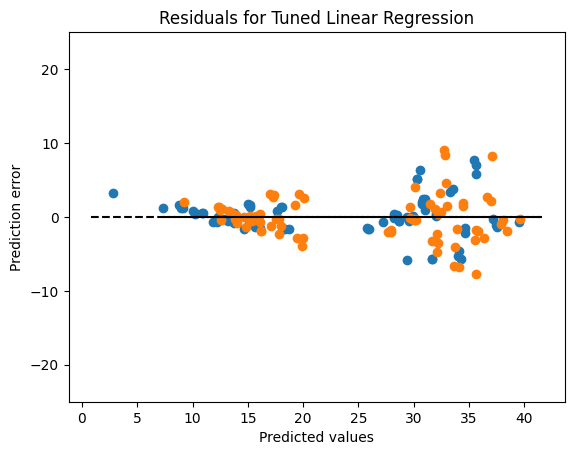

In [366]:
# Linear Regression (Tuned) - Energy Efficiency
yPredicted_simpLin_energy = SLRPredict
yError_simpLin_energy = y_test - yPredicted_simpLin_energy

fig = plt.figure()
plt.scatter(yPredicted_simpLin_energy[:, 0], yError_simpLin_energy['Y1'])  # Heating load
plt.scatter(yPredicted_simpLin_energy[:, 1], yError_simpLin_energy['Y2'])  # Cooling load
plt.title('Residuals for Tuned Linear Regression')
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
plt.ylim(-25, 25)
plt.plot([yPredicted_simpLin_energy[:, 0].min()-2, yPredicted_simpLin_energy[:, 0].max()+2], [0, 0], linestyle='dashed', color='black')
plt.plot([yPredicted_simpLin_energy[:, 1].min()-2, yPredicted_simpLin_energy[:, 1].max()+2], [0, 0], linestyle='dashed', color='black')
plt.show()

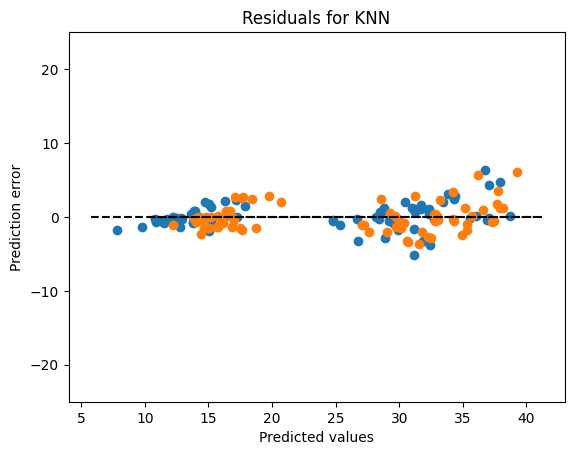

In [367]:
# Find predicted values
yPredicted_knnr = KNRegressorPredict

# Compute prediction errors
yError_knnr = y_test - yPredicted_knnr

# Plot prediction errors vs predicted values
fig = plt.figure()
plt.scatter(yPredicted_knnr[:, 0], yError_knnr['Y1'])  # Access the first column for x-axis
plt.scatter(yPredicted_knnr[:, 1], yError_knnr['Y2'])  # Access the second column for x-axis

plt.title('Residuals for KNN')
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
plt.ylim(-25, 25)

# Add dashed line at y=0
# Get min/max from the first column of predictions (adjust column index if needed)
plt.plot([yPredicted_knnr[:, 0].min() - 2, yPredicted_knnr[:, 0].max() + 2], [0, 0], linestyle='dashed', color='black')
plt.plot([yPredicted_knnr[:, 1].min() - 2, yPredicted_knnr[:, 1].max() + 2], [0, 0], linestyle='dashed', color='black')

plt.show()


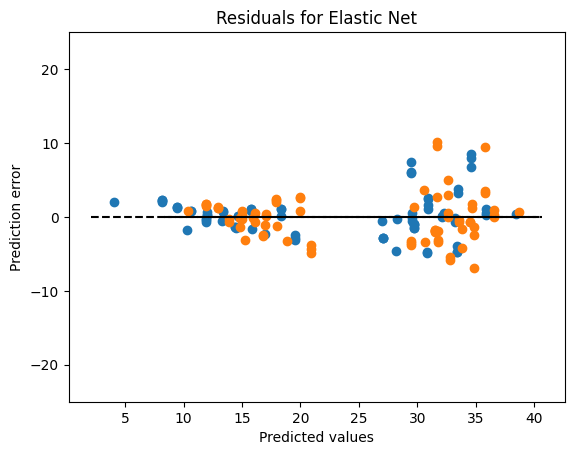

In [368]:
# Find predicted values
yPredicted_elasticNet = elasticNetPredict

# Compute prediction errors
yError_elasticNet = y_test - yPredicted_elasticNet

# Plot prediction errors vs predicted values
fig = plt.figure()
plt.scatter(yPredicted_elasticNet[:, 0], yError_elasticNet['Y1'])  # Access the first column for x-axis
plt.scatter(yPredicted_elasticNet[:, 1], yError_elasticNet['Y2'])  # Access the second column for x-axis

plt.title('Residuals for Elastic Net')
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
plt.ylim(-25, 25)

# Add dashed line at y=0
# Get min/max from the first column of predictions (adjust column index if needed)
plt.plot([yPredicted_elasticNet[:, 0].min() - 2, yPredicted_elasticNet[:, 0].max() + 2], [0, 0], linestyle='dashed', color='black')
plt.plot([yPredicted_elasticNet[:, 1].min() - 2, yPredicted_elasticNet[:, 1].max() + 2], [0, 0], linestyle='dashed', color='black')

plt.show()


In [369]:
# Combine scores from both models into a dataframe
df = pd.DataFrame({'Linear': [SLRModelEnergy], 'KNregressor': [KNRegressorModelEnergy]}, index=['Model'])

Text(0, 0.5, 'Cross-validation scores')

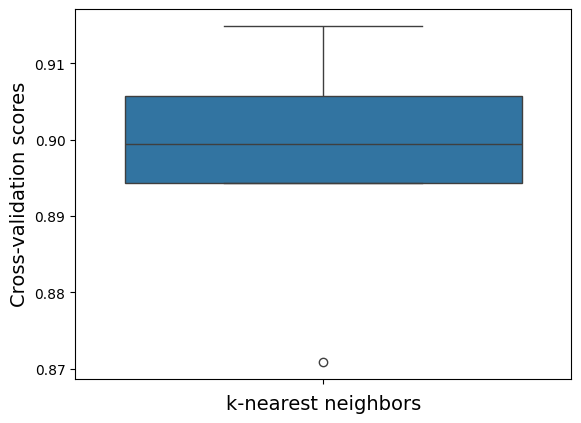

In [370]:
# Combine scores from both models into a dataframe
# Get model scores
linear_scores = SLRModelResults['test_score']  # Extract scores from cross-validation results
knn_scores = KNNModelResults['test_score']

# Create DataFrame with scores
df = pd.DataFrame({'Linear': linear_scores, 'KNregressor': knn_scores, 'Elastic Net': elasticNet_ValidationScores})

# Boxplot of errors for Linear Regression
p = sns.boxplot(data=df, y='Linear')
p.set_xlabel('k-nearest neighbors', fontsize=14)
p.set_ylabel('Cross-validation scores', fontsize=14)


Text(0, 0.5, 'Cross-validation scores')

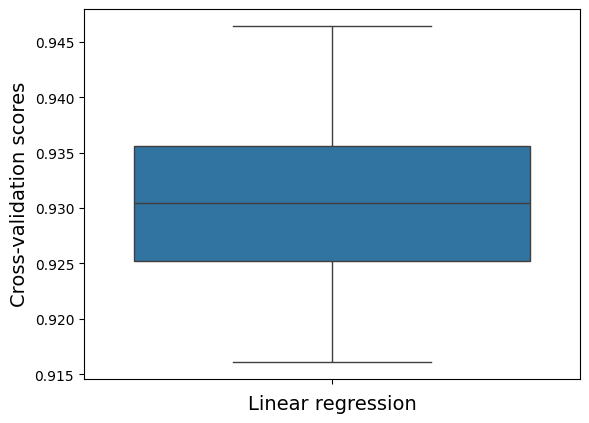

In [371]:
# Boxplot of errors for KN regression
p = sns.boxplot(data=df, y='KNregressor')
p.set_xlabel('Linear regression', fontsize=14)
p.set_ylabel('Cross-validation scores', fontsize=14)

Text(0, 0.5, 'Cross-validation scores')

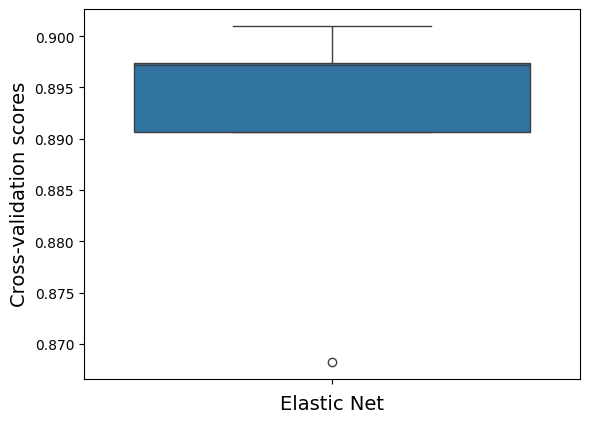

In [372]:
p = sns.boxplot(data=df, y='Elastic Net')
p.set_xlabel('Elastic Net', fontsize=14)
p.set_ylabel('Cross-validation scores', fontsize=14)

In [373]:
""" This is the Wine Quality Dataset: """

' This is the Wine Quality Dataset: '

# Wine Quality Dataset

In [374]:
#Loading the dataset
wine = pd.read_csv('winequality-red.csv', sep=';')
wine.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [375]:
#X contains the input features of the dataset:
Xwine= wine.iloc[:, 0:11]
#y contains the output features of the dataset:
ywine= wine[['quality']]
print(X.head())
print(y.head())

     X1     X2     X3      X4   X5  X6   X7  X8
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0
      Y1     Y2
0  15.55  21.33
1  15.55  21.33
2  15.55  21.33
3  15.55  21.33
4  20.84  28.28


In [376]:
#Prevent loss of original data by duplicating it before modification.
wine_encoded = wine.copy()

In [377]:
scalar = StandardScaler()
Xwine_processed = pd.DataFrame(scalar.fit_transform(Xwine), columns=Xwine.columns)

In [378]:
print(wine.head())
print(Xwine_processed.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [379]:
# prompt: Print amount of rows for Xwine_processed and ywine

print("Xwine_processed rows:", len(Xwine_processed))
print("ywine rows:", len(ywine))


Xwine_processed rows: 1599
ywine rows: 1599


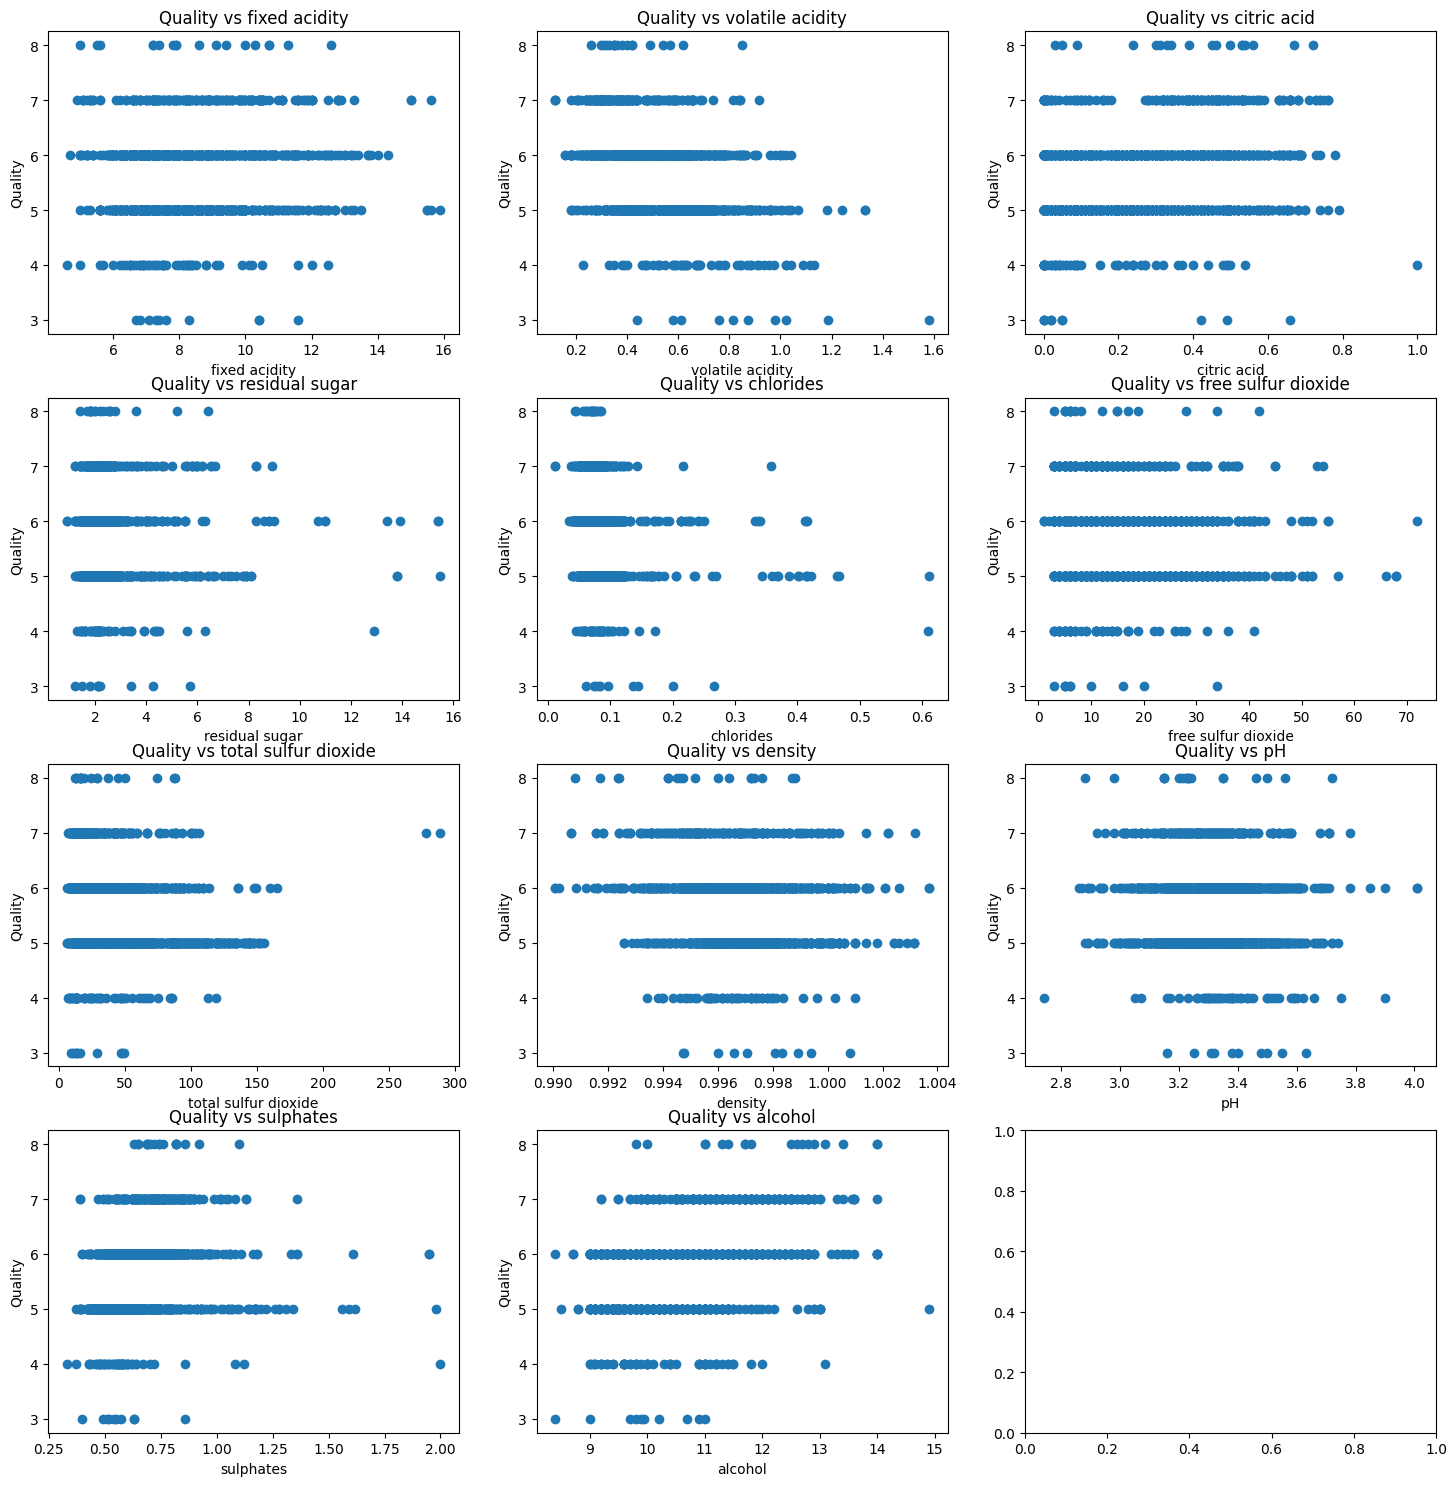

In [380]:
# prompt: put column names for wine into plots

# ... (Your existing code)

# Scatter plots for wine dataset
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.ravel()  # Flatten the axes array for easier iteration
fig.tight_layout(pad=2.5)


for i, col in enumerate(Xwine.columns):
    axes[i].scatter(Xwine[col], ywine)
    axes[i].set_title(f"Quality vs {col}")  # Set title with column name
    axes[i].set_xlabel(col)                # Set x-axis label
    axes[i].set_ylabel("Quality")          # Set y-axis label


plt.show()


In [381]:
#Split training and testing (10%) data:
X_train_val, X_test, y_train_val, y_test = train_test_split(Xwine_processed, ywine, test_size=0.1, random_state=11)
# Split again for validation (10%) and training data (80%)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1111, random_state=11)

#Cross-Validation
# Define a set of 10 cross-validation folds with random_state(For reproducibility)
kf = KFold(n_splits=5, random_state=11, shuffle=True)

X_train.shape

(1279, 11)

In [382]:
# Initialize a (Least Squares) linear regression model
SLRModelWine_base = LinearRegression()

# Initialize a Knnr regressor model
KNRegressorModelWine_base = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)          #Default hyperparameters

# Initialize a third model
elasticNetModelWine_base = ElasticNet(alpha=1, l1_ratio=0.5, max_iter=1000)


In [383]:
# Linear model performance on testing
#SLRModel.fit(X_train, np.ravel(y_train))
#SLRModel.score(X_test, np.ravel(y_test))
# Training:
SLRModelWine_base.fit(X_train, np.ravel(y_train)) # Remove np.ravel and use the original y_train DataFrame

print(X_train.columns)
print(SLRModelWine_base.coef_)
print(SLRModelWine_base.intercept_)



# Training:
KNRegressorModelWine_base.fit(X_train, np.ravel(y_train))

#print(KNRegressorModel.coef_)
#print(KNRegressorModel.intercept_)

# Training:
elasticNetModelWine_base.fit(X_train, np.ravel(y_train))

print(elasticNetModelWine_base.coef_)
print(elasticNetModelWine_base.intercept_)





Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
[ 0.09263909 -0.20265489 -0.03638322  0.03541126 -0.09843041  0.05027717
 -0.11446925 -0.06210023 -0.04307774  0.16746399  0.26675527]
5.624117853806803
[ 0. -0.  0.  0. -0. -0. -0. -0. -0.  0.  0.]
5.632525410476935


In [384]:
# Metrics
SLRPredict = SLRModelWine_base.predict(X_test)
KNRegressorPredict = KNRegressorModelWine_base.predict(X_test)
elasticNetPredict = elasticNetModelWine_base.predict(X_test)

print("This is the results before tuning:")

#Rsquared Testing
SLRModelWine_base.score(X_test, y_test)  # Remove np.ravel and use the original y_test DataFrame
print()
print("Least Squared Linear Regression metrics:")
print('R^2:', r2_score(y_test, SLRPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, SLRPredict)))
print('MAE:', mean_absolute_error(y_test, SLRPredict))
print('MSE:', mean_squared_error(y_test, SLRPredict))



#Rsquared Testing
KNRegressorModelWine_base.score(X_test, y_test)
print()
print("KNN Regression metrics:")
print('R^2:', r2_score(y_test, KNRegressorPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, KNRegressorPredict)))
print('MAE:', mean_absolute_error(y_test, KNRegressorPredict))
print('MSE:', mean_squared_error(y_test, KNRegressorPredict))



#Rsquared Testing
elasticNetModelWine_base.score(X_test, y_test)
print()
print("Elastic Net metrics:")
print('R^2:', r2_score(y_test, elasticNetPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, elasticNetPredict)))
print('MAE:', mean_absolute_error(y_test, elasticNetPredict))
print('MSE:', mean_squared_error(y_test, elasticNetPredict))








This is the results before tuning:

Least Squared Linear Regression metrics:
R^2: 0.2737888679028764
RMSE: 0.7227849840390767
MAE: 0.5648966968438002
MSE: 0.5224181331523683

KNN Regression metrics:
R^2: 0.26012163336229366
RMSE: 0.7295546586788408
MAE: 0.57125
MSE: 0.53225

Elastic Net metrics:
R^2: -0.0025078585649389584
RMSE: 0.8492226390971644
MAE: 0.7084343236903832
MSE: 0.7211790907551529


In [385]:
# Initialize a (Least Squares) linear regression model
SLRModel = LinearRegression()

# Initialize a Knnr regressor model
KNRegressorModel = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)          #Default hyperparameters

# Create a tuning grid for GridSearchCV.
k = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]}
# Initialize the tuning grid
knnTuning = GridSearchCV(KNRegressorModel, k, cv=kf)
# Fit the grid to the training data
knnTuning.fit(X_train, y_train)#np.ravel(y_train))


# Initialize a third model
elasticNetModel = ElasticNet(alpha=1, l1_ratio=0.5, max_iter=1000)
elasticTuning = GridSearchCV(elasticNetModel, {'alpha': [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 1, 10], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.8, 0.9]}, cv=kf)
elasticTuning.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=11, shuffle=True),
             estimator=ElasticNet(alpha=1),
             param_grid={'alpha': [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 1, 10],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.8, 0.9]})

Text(0, 0.5, 'Score')

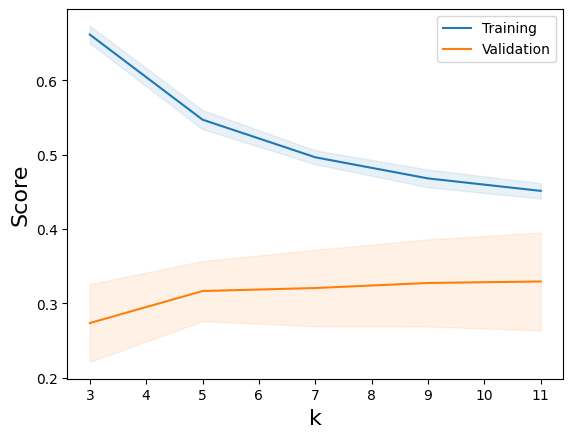

In [386]:
#KNN Validation Curve #1:
k = [3, 5, 7, 9, 11]
train_scores, test_scores = validation_curve(KNRegressorModel, X_train, y_train,
                                              param_range=k,
                                              param_name='n_neighbors',
                                              cv=5)
                                              #scoring='neg_mean_squared_error'n_jobs????


# Calculate mean and SD for training and testing
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot cross-validation results on training/validation for each parameter value
sns.lineplot(x=k, y=train_scores_mean, label='Training', color='#1f77b4')
sns.lineplot(x=k, y=test_scores_mean, label='Validation', color='#ff7f0e')
plt.fill_between(k, train_scores_mean-train_scores_std, train_scores_mean+train_scores_std,
                 alpha=0.1, color='#1f77b4')
plt.fill_between(k, test_scores_mean-test_scores_std, test_scores_mean+test_scores_std,
                 alpha=0.1, color='#ff7f0e')

plt.xlabel('k', fontsize=16)
plt.ylabel('Score', fontsize=16)

Text(0, 0.5, 'Score')

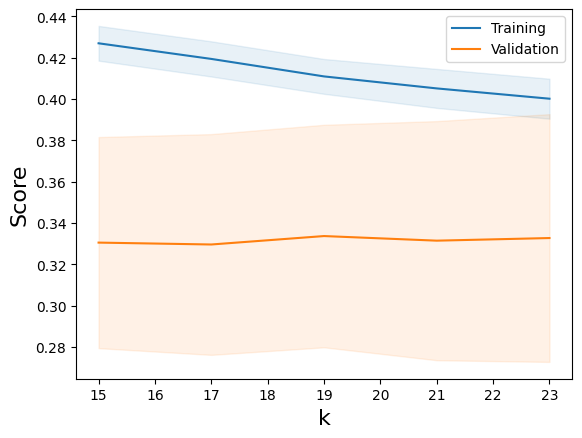

In [387]:
#KNN validation Curve #2
k = [15, 17, 19, 21, 23]
train_scores, test_scores = validation_curve(KNRegressorModel, X_train, y_train,
                                              param_range=k,
                                              param_name='n_neighbors',
                                              cv=5)
                                              #scoring='neg_mean_squared_error'n_jobs????


# Calculate mean and SD for training and testing
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot cross-validation results on training/validation for each parameter value
sns.lineplot(x=k, y=train_scores_mean, label='Training', color='#1f77b4')
sns.lineplot(x=k, y=test_scores_mean, label='Validation', color='#ff7f0e')
plt.fill_between(k, train_scores_mean-train_scores_std, train_scores_mean+train_scores_std,
                 alpha=0.1, color='#1f77b4')
plt.fill_between(k, test_scores_mean-test_scores_std, test_scores_mean+test_scores_std,
                 alpha=0.1, color='#ff7f0e')

plt.xlabel('k', fontsize=16)
plt.ylabel('Score', fontsize=16)

<Axes: >

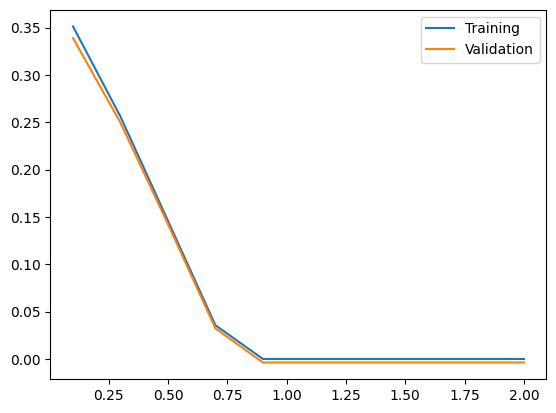

In [388]:
elastic = [0.1, 0.3, 0.5, 0.7, 0.9, 1, 2]
train_scores, test_scores = validation_curve(elasticNetModel, X_train, y_train,
                                              param_range=elastic,
                                              param_name='alpha',
                                              cv=5)

# Calculate mean and SD for training and testing for elastic net
train_scores_mean = np.mean(train_scores, axis=1) # Calculate mean for elastic net
train_scores_std = np.std(train_scores, axis=1)  # Calculate std for elastic net
test_scores_mean = np.mean(test_scores, axis=1)   # Calculate mean for elastic net
test_scores_std = np.std(test_scores, axis=1)    # Calculate std for elastic net


sns.lineplot(x=elastic, y=train_scores_mean, label='Training', color='#1f77b4')
sns.lineplot(x=elastic, y=test_scores_mean, label='Validation', color='#ff7f0e')

<Axes: >

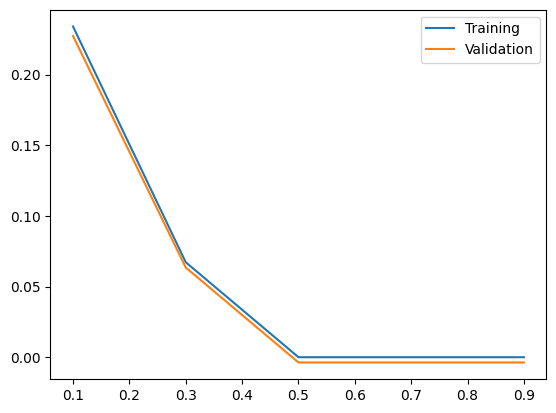

In [389]:
l1_ratio_range = [0.1, 0.3, 0.5, 0.7, 0.9]

train_scores, test_scores = validation_curve(elasticNetModel, X_train, y_train,
                                              param_range=l1_ratio_range,
                                              param_name='l1_ratio',
                                              cv=5)

# Calculate mean and SD for training and testing for elastic net
train_scores_mean = np.mean(train_scores, axis=1) # Calculate mean for elastic net
train_scores_std = np.std(train_scores, axis=1)  # Calculate std for elastic net
test_scores_mean = np.mean(test_scores, axis=1)   # Calculate mean for elastic net
test_scores_std = np.std(test_scores, axis=1)    # Calculate std for elastic net


sns.lineplot(x=l1_ratio_range, y=train_scores_mean, label='Training', color='#1f77b4')
sns.lineplot(x=l1_ratio_range, y=test_scores_mean, label='Validation', color='#ff7f0e')

In [390]:
knnTuning.cv_results_

{'mean_fit_time': array([0.00633526, 0.00726032, 0.00555029, 0.00508542, 0.00518885,
        0.00562668, 0.00475564, 0.00472145, 0.00463123, 0.00475798,
        0.00532675, 0.00510645]),
 'std_fit_time': array([1.66485516e-03, 2.97271510e-03, 1.00262327e-03, 5.28294285e-04,
        6.79922346e-04, 2.00291196e-03, 1.36989813e-04, 2.06061491e-04,
        8.05014110e-05, 9.06109300e-05, 6.45944936e-04, 6.71813620e-04]),
 'mean_score_time': array([0.01515965, 0.01917462, 0.01606121, 0.01530571, 0.01579013,
        0.01613822, 0.01604042, 0.0163939 , 0.01668448, 0.01692696,
        0.02020359, 0.01801548]),
 'std_score_time': array([0.00195631, 0.00383989, 0.00162603, 0.00047783, 0.00125069,
        0.00069242, 0.00036089, 0.00014751, 0.00021998, 0.00033405,
        0.00093529, 0.0008194 ]),
 'param_n_neighbors': masked_array(data=[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25],
              mask=[False, False, False, False, False, False, False, False,
                    False, False, False,

In [391]:
print(len([key for key in knnTuning.cv_results_.keys() if 'split' in key]))


5


In [392]:
# Mean testing score for each k and best hyperparameters
print('Mean testing scores:', knnTuning.cv_results_['mean_test_score'])
print("\nAccording to the GridSearchCV results, the best hyperparameter value is:", knnTuning.best_estimator_)



Mean testing scores: [0.27584331 0.31145459 0.31039344 0.32601044 0.32516275 0.32145421
 0.33098655 0.33323428 0.33231041 0.33511026 0.33619078 0.33650926]

According to the GridSearchCV results, the best hyperparameter value is: KNeighborsRegressor(n_neighbors=25)


In [393]:
elasticTuning.cv_results_

{'mean_fit_time': array([0.00403199, 0.00413332, 0.00365911, 0.00357327, 0.00369067,
        0.00370173, 0.00371313, 0.00357208, 0.0035213 , 0.00354815,
        0.00427675, 0.00470691, 0.00448761, 0.00421476, 0.00422096,
        0.00373635, 0.00448523, 0.00370407, 0.00387182, 0.00371065,
        0.00368991, 0.00435309, 0.00409226, 0.00514989, 0.00450292,
        0.00405264, 0.00420537, 0.00402603, 0.0042809 , 0.00422578,
        0.0043714 , 0.00425849, 0.00439453, 0.00431142, 0.00382261,
        0.00380707, 0.0037899 , 0.00257864, 0.00256443, 0.00258694,
        0.00246954, 0.00253134, 0.00415993, 0.00266151, 0.00294609,
        0.00300488, 0.00296159, 0.00306029]),
 'std_fit_time': array([2.18620118e-04, 2.24909717e-04, 6.94004664e-05, 2.44188118e-05,
        1.02524913e-04, 2.18583495e-04, 3.77960756e-05, 6.99805603e-05,
        1.70235540e-05, 5.79507243e-05, 8.28679999e-04, 4.31666629e-04,
        9.48194467e-04, 1.96439027e-04, 2.44568891e-04, 4.74951655e-04,
        4.82531818e-0

In [394]:
# Mean testing score
print('Mean testing scores:', elasticTuning.cv_results_['mean_test_score'])
print("\nAccording to the GridSearchCV results, the best hyperparameter value is:", elasticTuning.best_estimator_)

Mean testing scores: [ 0.35669582  0.34974965  0.33822078  0.32247285  0.31593329  0.31034254
  0.33645304  0.29159578  0.24675761  0.19731855  0.16750499  0.1326965
  0.30694978  0.22638986  0.13837347  0.03386262 -0.00343905 -0.00586499
  0.27361667  0.15946157  0.02845028 -0.00586499 -0.00586499 -0.00586499
  0.25650105  0.12650516 -0.00393701 -0.00586499 -0.00586499 -0.00586499
  0.24002221  0.09325266 -0.00586499 -0.00586499 -0.00586499 -0.00586499
  0.22445464  0.06002931 -0.00586499 -0.00586499 -0.00586499 -0.00586499
 -0.00586499 -0.00586499 -0.00586499 -0.00586499 -0.00586499 -0.00586499]

According to the GridSearchCV results, the best hyperparameter value is: ElasticNet(alpha=0.1, l1_ratio=0.1)


In [395]:
knnTuning_best = knnTuning.best_estimator_
elasticTuning_best = elasticTuning.best_estimator_

In [396]:
# Post-Tuning Validation Scores

# Linear Regression:
# Fit simple linear regression with cross-validation to the training data (SLRModel stores results and both training and validation scores)
SLRModelResults = cross_validate(SLRModelEnergy, X_train, y_train, cv=kf, return_train_score=True)    #Cross validate trains model based on folds (train_test_score tests for overfitting)
# Find the test score for each fold
SLR_ValidationScores = SLRModelResults['test_score']
print('Simple linear regression scores:', SLR_ValidationScores.round(3))                        #Display test scores to the third decimal

# KNNModel:
KNNModelResults = cross_validate(knnTuning_best, X_train, y_train, cv=kf, return_train_score=True)
KNRegressor_ValidationScores = KNNModelResults['test_score']
print('KNN scores:', KNRegressor_ValidationScores.round(3))

# Elastic Net:
elasticNetModelResults = cross_validate(elasticTuning_best, X_train, y_train, cv=kf, return_train_score=True)
elasticNet_ValidationScores = elasticNetModelResults['test_score']
print('Elastic Net scores:', elasticNet_ValidationScores.round(3))

Simple linear regression scores: [0.412 0.244 0.366 0.425 0.349]
KNN scores: [0.377 0.292 0.341 0.37  0.303]
Elastic Net scores: [0.406 0.265 0.361 0.406 0.346]


In [397]:
# Validation
print('Mean:', SLR_ValidationScores.mean().round(3))
print('SD:', SLR_ValidationScores.std().round(3))

print('Mean:', KNRegressor_ValidationScores.mean().round(3))
print('SD:', KNRegressor_ValidationScores.std().round(3))

#3rd model
print('Mean:', elasticNet_ValidationScores.mean().round(3))
print('SD:', elasticNet_ValidationScores.std().round(3))

Mean: 0.359
SD: 0.064
Mean: 0.337
SD: 0.034
Mean: 0.357
SD: 0.052


In [398]:
# prompt: Print what the hyperparameters are for KNRegressor?

print(KNRegressorModelEnergy.get_params())


{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [399]:
# Model with the best hyperparameter
knnTuning_best = knnTuning.best_estimator_

elasticTuning_best = elasticTuning.best_estimator_


In [400]:
# Logistic model performance on testing
#SLRModel.fit(X_train, np.ravel(y_train))
#SLRModel.score(X_test, np.ravel(y_test))
# Training:
SLRModel.fit(X_train, y_train) # Remove np.ravel and use the original y_train DataFrame

print(X_train.columns)
print(SLRModel.coef_)
print(SLRModel.intercept_)



# Training:
knnTuning_best.fit(X_train, y_train)

#print(KNRegressorModel.coef_)
#print(KNRegressorModel.intercept_)

# Training:
elasticTuning_best.fit(X_train, y_train)

#print(elasticNetModel.coef_)
#print(elasticNetModel.intercept_)





Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')
[[ 0.09263909 -0.20265489 -0.03638322  0.03541126 -0.09843041  0.05027717
  -0.11446925 -0.06210023 -0.04307774  0.16746399  0.26675527]]
[5.62411785]


ElasticNet(alpha=0.1, l1_ratio=0.1)

In [401]:
# Metrics
SLRPredict = SLRModel.predict(X_test)
KNRegressorPredict = knnTuning_best.predict(X_test)
elasticNetPredict = elasticTuning_best.predict(X_test)

print("This is the results after tuning:")

#Rsquared Testing
#SLRModelWine.score(X_test, y_test)  # Remove np.ravel and use the original y_test DataFrame
print()
print("Least Squared Linear Regression metrics:")
print('R^2:', r2_score(y_test, SLRPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, SLRPredict)))
print('MAE:', mean_absolute_error(y_test, SLRPredict))
print('MSE:', mean_squared_error(y_test, SLRPredict))



#Rsquared Testing
#KNRegressorModelWine.score(X_test, y_test)
print()
print("KNN Regression metrics:")
print('R^2:', r2_score(y_test, KNRegressorPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, KNRegressorPredict)))
print('MAE:', mean_absolute_error(y_test, KNRegressorPredict))
print('MSE:', mean_squared_error(y_test, KNRegressorPredict))



#Rsquared Testing
#elasticNetModelWine.score(X_test, y_test)
print()
print("Elastic Net metrics:")
print('R^2:', r2_score(y_test, elasticNetPredict))
print('RMSE:', np.sqrt(mean_squared_error(y_test, elasticNetPredict)))
print('MAE:', mean_absolute_error(y_test, elasticNetPredict))
print('MSE:', mean_squared_error(y_test, elasticNetPredict))








This is the results after tuning:

Least Squared Linear Regression metrics:
R^2: 0.2737888679028764
RMSE: 0.7227849840390767
MAE: 0.5648966968438002
MSE: 0.5224181331523683

KNN Regression metrics:
R^2: 0.26843440486533454
RMSE: 0.7254446912067108
MAE: 0.56425
MSE: 0.52627

Elastic Net metrics:
R^2: 0.27237976087975835
RMSE: 0.7234858737509142
MAE: 0.5679249230494767
MSE: 0.5234318095171238


In [402]:
# This code needs debugging.
# Linear Regression (Tuned) - Wine
"""
yPredicted_simpLin_Wine = SLRPredict
yError_simpLin_Wine = y_test - yPredicted_simpLin_Wine

fig = plt.figure()
plt.scatter(yPredicted_simpLin_Wine[:, 0], yError_simpLin_Wine['Y1'])  # Heating load
plt.scatter(yPredicted_simpLin_Wine[:, 1], yError_simpLin_Wine['Y2'])  # Cooling load
plt.title('Residuals for Tuned Linear Regression - Wine Efficiency')
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
plt.ylim(-25, 25)
plt.plot([yPredicted_simpLin_Wine[:, 0].min()-2, yPredicted_simpLin_Wine[:, 0].max()+2], [0, 0], linestyle='dashed', color='black')
plt.plot([yPredicted_simpLin_Wine[:, 1].min()-2, yPredicted_simpLin_Wine[:, 1].max()+2], [0, 0], linestyle='dashed', color='black')
plt.show()
"""

"\nyPredicted_simpLin_Wine = SLRPredict\nyError_simpLin_Wine = y_test - yPredicted_simpLin_Wine\n\nfig = plt.figure()\nplt.scatter(yPredicted_simpLin_Wine[:, 0], yError_simpLin_Wine['Y1'])  # Heating load\nplt.scatter(yPredicted_simpLin_Wine[:, 1], yError_simpLin_Wine['Y2'])  # Cooling load\nplt.title('Residuals for Tuned Linear Regression - Wine Efficiency')\nplt.xlabel('Predicted values')\nplt.ylabel('Prediction error')\nplt.ylim(-25, 25)\nplt.plot([yPredicted_simpLin_Wine[:, 0].min()-2, yPredicted_simpLin_Wine[:, 0].max()+2], [0, 0], linestyle='dashed', color='black')\nplt.plot([yPredicted_simpLin_Wine[:, 1].min()-2, yPredicted_simpLin_Wine[:, 1].max()+2], [0, 0], linestyle='dashed', color='black')\nplt.show()\n"

In [403]:
# This code needs debugging.
# Linear Regression (Tuned) - Wine Quality"
"""
yPredicted_simpLin_Wine = SLRPredict
yError_simpLin_Wine = np.ravel(y_test) - yPredicted_simpLin_Wine

fig = plt.figure()
# The wine quality dataset only has one target variable, 'quality'
plt.title('Linear Regression')
plt.scatter(yPredicted_simpLin_Wine, yError_simpLin_Wine['quality'])
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
#plt.ylim(-25, 25) # Adjust ylim if needed
plt.plot([yPredicted_simpLin_Wine.min()-2, yPredicted_simpLin_Wine.max()+2], [0, 0], linestyle='dashed', color='black')
plt.show()
"""

"\nyPredicted_simpLin_Wine = SLRPredict\nyError_simpLin_Wine = np.ravel(y_test) - yPredicted_simpLin_Wine\n\nfig = plt.figure()\n# The wine quality dataset only has one target variable, 'quality'\nplt.title('Linear Regression')\nplt.scatter(yPredicted_simpLin_Wine, yError_simpLin_Wine['quality'])  \nplt.xlabel('Predicted values')\nplt.ylabel('Prediction error')\n#plt.ylim(-25, 25) # Adjust ylim if needed\nplt.plot([yPredicted_simpLin_Wine.min()-2, yPredicted_simpLin_Wine.max()+2], [0, 0], linestyle='dashed', color='black')\nplt.show()\n"

In [404]:
# This code needs debugging.
# Linear Regression (Tuned) - Wine Quality
"""
yPredicted_simpLin_Wine = SLRPredict
yError_simpLin_Wine = np.ravel(y_test) - yPredicted_simpLin_Wine  # yError_simpLin_Wine is now a NumPy array

fig = plt.figure()
# The wine quality dataset only has one target variable, 'quality'
plt.title('Linear Regression')
# Access elements of yError_simpLin_Wine using numerical indices, e.g., yError_simpLin_Wine[:, 0] for the first column
plt.scatter(yPredicted_simpLin_Wine, yError_simpLin_Wine)
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
#plt.ylim(-25, 25) # Adjust ylim if needed
plt.plot([yPredicted_simpLin_Wine.min()-2, yPredicted_simpLin_Wine.max()+2], [0, 0], linestyle='dashed', color='black')
plt.show()
"""

"\nyPredicted_simpLin_Wine = SLRPredict\nyError_simpLin_Wine = np.ravel(y_test) - yPredicted_simpLin_Wine  # yError_simpLin_Wine is now a NumPy array\n\nfig = plt.figure()\n# The wine quality dataset only has one target variable, 'quality'\nplt.title('Linear Regression')\n# Access elements of yError_simpLin_Wine using numerical indices, e.g., yError_simpLin_Wine[:, 0] for the first column\nplt.scatter(yPredicted_simpLin_Wine, yError_simpLin_Wine)  \nplt.xlabel('Predicted values')\nplt.ylabel('Prediction error')\n#plt.ylim(-25, 25) # Adjust ylim if needed\nplt.plot([yPredicted_simpLin_Wine.min()-2, yPredicted_simpLin_Wine.max()+2], [0, 0], linestyle='dashed', color='black')\nplt.show()\n"

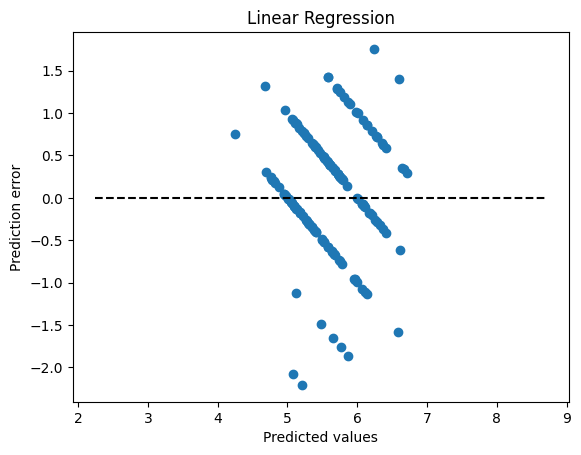

In [405]:
# Linear Regression (Tuned) - Wine Quality
yPredicted_simpLin_Wine = SLRPredict
# Ensure y_test and yPredicted_simpLin_Wine have compatible shapes
yError_simpLin_Wine = y_test['quality'].values - yPredicted_simpLin_Wine.ravel()  # Use .values for y_test and ravel for yPredicted_simpLin_Wine

fig = plt.figure()
# The wine quality dataset only has one target variable, 'quality'
plt.title('Linear Regression')
# Access elements of yError_simpLin_Wine using numerical indices, e.g., yError_simpLin_Wine[:, 0] for the first column
plt.scatter(yPredicted_simpLin_Wine, yError_simpLin_Wine)
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
#plt.ylim(-25, 25) # Adjust ylim if needed
plt.plot([yPredicted_simpLin_Wine.min()-2, yPredicted_simpLin_Wine.max()+2], [0, 0], linestyle='dashed', color='black')
plt.show()

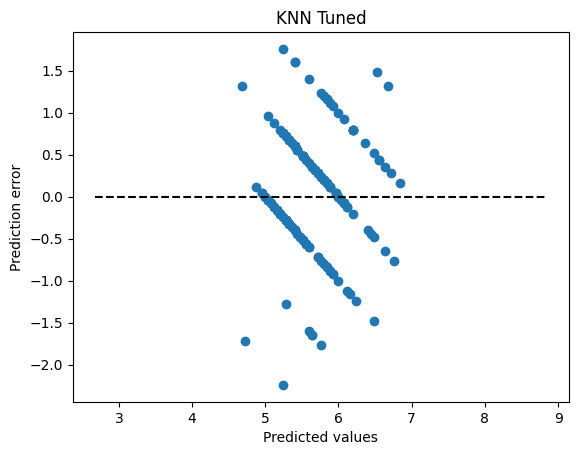

In [406]:
# Linear Regression (Tuned) - Wine Quality
yPredicted_KNN_Wine = KNRegressorPredict
yError_KNN_Wine = y_test - yPredicted_KNN_Wine

fig = plt.figure()
# The wine quality dataset only has one target variable, 'quality'
plt.title('KNN Tuned')
plt.scatter(yPredicted_KNN_Wine, yError_KNN_Wine['quality'])
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
#plt.ylim(-25, 25) # Adjust ylim if needed
plt.plot([yPredicted_KNN_Wine.min()-2, yPredicted_KNN_Wine.max()+2], [0, 0], linestyle='dashed', color='black')
plt.show()

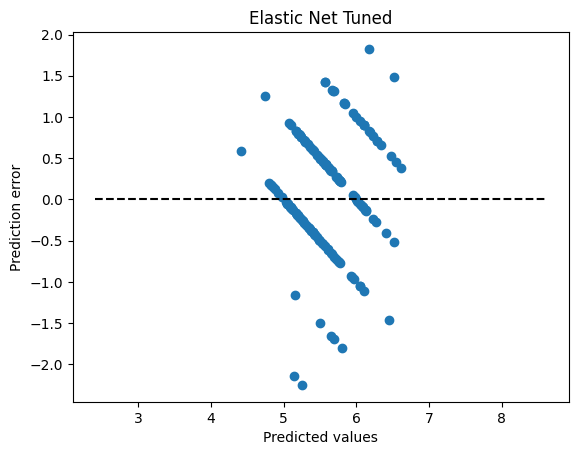

In [407]:
# Linear Regression (Tuned) - Wine Quality
yPredicted_KNN_Wine = elasticNetPredict
yError_KNN_Wine = y_test['quality'] - yPredicted_KNN_Wine # Subtracting from the 'quality' Series instead

fig = plt.figure()
# The wine quality dataset only has one target variable, 'quality'
plt.title('Elastic Net Tuned')
plt.scatter(yPredicted_KNN_Wine, yError_KNN_Wine)
plt.xlabel('Predicted values')
plt.ylabel('Prediction error')
#plt.ylim(-25, 25) # Adjust ylim if needed
plt.plot([yPredicted_KNN_Wine.min()-2, yPredicted_KNN_Wine.max()+2], [0, 0], linestyle='dashed', color='black')
plt.show()